# sample7 - 転移学習（Transfer Learning）

事前学習済みモデル（ResNet18）を再利用して、少ないデータでも高精度な分類を実現します。  
ここでは **CIFAR-10** の一部データを使い、転移学習の基本パターンを学びます。

| ステップ | 内容 |
|----------|------|
| 1 | 転移学習の考え方 |
| 2 | 事前学習済みモデルの読み込み |
| 3 | 最終層の差し替え（Fine-tuning） |
| 4 | データ準備（torchvision） |
| 5 | 学習・評価 |

## 1. 転移学習の考え方

```
事前学習済みモデル（ImageNet 1000クラスで学習済み）
  ├── 特徴抽出層（凍結） ← そのまま再利用
  └── 最終分類層        ← 自分のクラス数に差し替えて学習
```

- **特徴抽出層の凍結**: `requires_grad = False` にして学習しない
- **最終層のみ学習**: 自分のタスクに合わせた出力層だけ更新する

## 2. 事前学習済みモデルの読み込み

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用デバイス:", device)

# ResNet18 の事前学習済みモデルを読み込む
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print("ResNet18 最終層:", model.fc)  # Linear(512, 1000) ← ImageNet 1000クラス

使用デバイス: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/user/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


ResNet18 最終層: Linear(in_features=512, out_features=1000, bias=True)


## 3. 最終層の差し替え（Fine-tuning）

In [2]:
# Step 1: 全層を凍結
for param in model.parameters():
    param.requires_grad = False

# Step 2: 最終層を CIFAR-10 用（10クラス）に差し替え
num_features = model.fc.in_features  # 512
model.fc = nn.Linear(num_features, 10)  # 最終層だけ学習可能

model = model.to(device)

# 学習可能パラメータの確認
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"学習可能パラメータ: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

学習可能パラメータ: 5,130 / 11,181,642 (0.0%)


## 4. データ準備（CIFAR-10）

初回実行時にデータが自動ダウンロードされます（約170MB）。

In [3]:
# ResNet は 224x224 を期待しているので Resize する
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet の統計値
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# 学習時間短縮のため各クラス100枚（計1000枚）に絞る
indices = [i for i in range(len(train_dataset)) if train_dataset.targets[i] < 10]
indices = indices[:1000]
train_subset = Subset(train_dataset, indices)
test_subset  = Subset(test_dataset,  list(range(500)))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=32, shuffle=False, num_workers=2)

classes = train_dataset.classes
print("クラス:", classes)
print("学習データ:", len(train_subset), "/ テストデータ:", len(test_subset))

100.0%
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


クラス: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
学習データ: 1000 / テストデータ: 500


## 5. 学習・評価

In [4]:
criterion = nn.CrossEntropyLoss()
# 最終層のみ optimizer に渡す
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 10
train_losses, val_accs = [], []

for epoch in range(epochs):
    # --- 学習 ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    # --- 評価 ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = torch.argmax(model(X_batch), dim=1)
            correct += (pred == y_batch).sum().item()
            total   += y_batch.size(0)
    acc = correct / total
    val_accs.append(acc)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {train_losses[-1]:.4f} | Val Acc: {acc:.4f}")

Epoch [1/10] Loss: 2.1399 | Val Acc: 0.4320
Epoch [2/10] Loss: 1.5051 | Val Acc: 0.5860
Epoch [3/10] Loss: 1.2049 | Val Acc: 0.6420
Epoch [4/10] Loss: 1.0042 | Val Acc: 0.6880
Epoch [5/10] Loss: 0.9364 | Val Acc: 0.6620
Epoch [6/10] Loss: 0.8220 | Val Acc: 0.6960
Epoch [7/10] Loss: 0.7708 | Val Acc: 0.6780
Epoch [8/10] Loss: 0.7195 | Val Acc: 0.6880
Epoch [9/10] Loss: 0.6593 | Val Acc: 0.6940
Epoch [10/10] Loss: 0.6671 | Val Acc: 0.7060


/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 36578 (\N{CJK UNIFIED IDEOGRAPH-8EE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51225/2505874227.py:12: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/IPyth

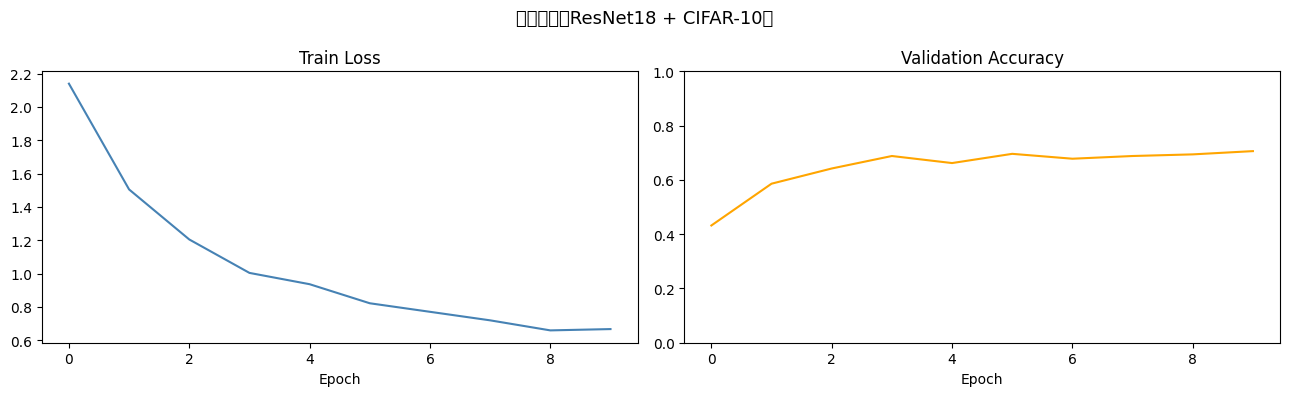

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(val_accs, color='orange')
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

plt.suptitle("転移学習（ResNet18 + CIFAR-10）", fontsize=13)
plt.tight_layout()
plt.show()